# 02 — Raw Layer Exploration: Yellow Taxi Parquet-Dateien (vor Ingestion)

Dieses Notebook schaut sich die rohen NYC Yellow Taxi Parquet-Dateien an, bevor sie via
`spark-ingestion.py` in Iceberg/Nessie landen. Ziel: verstehen was tatsaechlich in den Dateien
steckt, bevor wir eine Ingestion-Strategie (Schema-Normalisierung, Partitionierung) festlegen.

Der NYC TLC hat sein Datei-Schema ueber die Jahre mehrfach geaendert (u.a. 2015). Mit nur
`yellow_tripdata_2009-01.parquet` sehen wir das noch nicht -- sobald weitere Monate/Jahre
dazukommen, werden hier automatisch Schema-Abweichungen sichtbar.

Hinweis zum Pfad: `spark_init.get_spark_session` verbindet zu einem Spark-Cluster
(Master + Worker in eigenen Containern). Der relative Pfad `../mini_lakehouse/data/yellow_taxi`
muss daher identisch in allen Spark-Containern gemountet sein, nicht nur im Jupyter-Container --
sonst listet `os.listdir()` die Dateien zwar erfolgreich auf, aber `spark.read.parquet()`
schlaegt auf den Workern fehl, weil die dort den Pfad nicht sehen. Die Zelle weiter unten
prueft das explizit, bevor wir groessere Reads starten.

In [1]:
import sys
sys.path.insert(0, "/home/jovyan/notebooks")
from spark_init import get_spark_session

spark = get_spark_session("02-taxi-raw-exploration")

Lakehouse Helpers geladen


---
## Welche Dateien liegen im Ordner?

Erst mal simpel: Python-seitig auflisten (laeuft im Jupyter-Kernel, nicht im Cluster).

In [2]:
import os
import re
from pathlib import Path
from collections import defaultdict

DATA_DIR = "../data/yellow_taxi"

def extract_year(filename):
    match = re.search(r"yellow_tripdata_(\d{4})-\d{2}\.parquet", filename)
    if not match:
        raise ValueError("Dateiname passt nicht ins erwartete Muster: " + filename)
    return int(match.group(1))

# Define min max year for schema compatibility
min_year = 2011
max_year = 2023

all_files = sorted(Path(DATA_DIR).glob("yellow_tripdata_*.parquet"))
files = [f for f in all_files if extract_year(f.name) >= min_year and extract_year(f.name) <= max_year ]

skipped = len(all_files) - len(files)
print(str(len(files)) + " Datei(en) gefunden in " + DATA_DIR + " (>= 2011 and <= 2023)")
if skipped:
    print(str(skipped) + " Datei(en) < 2011 uebersprungen")
print("")

# Print per year
year_stats = defaultdict(lambda: {"count": 0, "size_mb": 0.0})
skipped = 0

for f in files:
    year = extract_year(f.name)
    if year < min_year or year > max_year:
        skipped += 1
        continue
    size_mb = f.stat().st_size / (1024 * 1024)
    year_stats[year]["count"] += 1
    year_stats[year]["size_mb"] += size_mb

print("Jahr".ljust(10) + "Dateien".rjust(10) + "Groesse (MB)".rjust(15))
print("-" * 35)
total_count = 0
total_size = 0.0
for year in sorted(year_stats.keys()):
    stats = year_stats[year]
    print(str(year).ljust(10) + str(stats["count"]).rjust(10) + str(round(stats["size_mb"])).rjust(15))
    total_count += stats["count"]
    total_size += stats["size_mb"]


156 Datei(en) gefunden in ../data/yellow_taxi (>= 2011 and <= 2023)
48 Datei(en) < 2011 uebersprungen

Jahr         Dateien   Groesse (MB)
-----------------------------------
2011              12           2106
2012              12           2083
2013              12           2045
2014              12           2049
2015              12           1933
2016              12           1748
2017              12           1521
2018              12           1397
2019              12           1186
2020              12            357
2021              12            457
2022              12            587
2023              12            606


### Sichtbarkeitscheck: sieht der Cluster den Pfad genauso wie der Jupyter-Kernel?

Kurzer Read der ersten Datei -- schlaegt das fehl, ist der Mount-Pfad zwischen Jupyter- und
Spark-Containern unterschiedlich, und wir muessen `DATA_DIR` auf einen Pfad aendern, der in
der `docker-compose.yml` fuer alle Spark-Services (master, worker) gemountet ist.

In [3]:
assert files, "Keine Dateien gefunden - DATA_DIR pruefen (relativ zum Jupyter-Arbeitsverzeichnis)."

try:
    probe_df = spark.read.parquet(str(files[0]))
    probe_count = probe_df.count()
    print("OK: Cluster kann " + files[0].name + " lesen (" + str(probe_count) + " Zeilen).")
except Exception as e:
    print("FEHLER: Spark-Worker koennen den Pfad vermutlich nicht sehen.")
    print("Pruefe die Volume-Mounts in docker-compose.yml fuer spark-master/spark-worker.")
    raise

OK: Cluster kann yellow_tripdata_2011-01.parquet lesen (13464997 Zeilen).


---
## Schema pro Datei -- wo weicht was ab?

Statt anzunehmen, dass alle Dateien das gleiche Schema haben, lesen wir jede Datei einzeln
und sammeln ihre Spaltennamen. So sehen wir Schema-Bruchstellen (z.B. 2015), sobald mehr
Dateien im Ordner liegen -- mit nur der 2009-01-Datei gibt es hier naturgemaess noch nichts zu vergleichen.

In [4]:
import re

def extract_year(filename):
    match = re.search(r"yellow_tripdata_(\d{4})-\d{2}\.parquet", filename)
    if not match:
        raise ValueError("Dateiname passt nicht ins erwartete Muster: " + filename)
    return match.group(1)

# Ein Sample-File pro Jahr auswaehlen (jeweils das erste sortierte, meist -01)
files_by_year = {}
for f in files:
    year = extract_year(f.name)
    files_by_year.setdefault(year, f)  # erstes Vorkommen pro Jahr behalten

print(str(len(files_by_year)) + " Jahr(e) erkannt, jeweils 1 Sample-Datei zur Schema-Pruefung:")
for year, f in sorted(files_by_year.items()):
    print("  " + year + " -> " + f.name)

file_schemas = {}
for year, f in sorted(files_by_year.items()):
    df = spark.read.parquet(str(f))
    file_schemas[year] = df.columns
    print("")
    print(year + " (" + f.name + ")  (" + str(len(df.columns)) + " Spalten)")
    print("  " + ", ".join(df.columns))

13 Jahr(e) erkannt, jeweils 1 Sample-Datei zur Schema-Pruefung:
  2011 -> yellow_tripdata_2011-01.parquet
  2012 -> yellow_tripdata_2012-01.parquet
  2013 -> yellow_tripdata_2013-01.parquet
  2014 -> yellow_tripdata_2014-01.parquet
  2015 -> yellow_tripdata_2015-01.parquet
  2016 -> yellow_tripdata_2016-01.parquet
  2017 -> yellow_tripdata_2017-01.parquet
  2018 -> yellow_tripdata_2018-01.parquet
  2019 -> yellow_tripdata_2019-01.parquet
  2020 -> yellow_tripdata_2020-01.parquet
  2021 -> yellow_tripdata_2021-01.parquet
  2022 -> yellow_tripdata_2022-01.parquet
  2023 -> yellow_tripdata_2023-01.parquet

2011 (yellow_tripdata_2011-01.parquet)  (19 Spalten)
  VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, airport_fee

2012 (yellow_tripdata_2012-01.parquet)  (19 Sp

In [5]:
# Alle Spaltennamen ueber alle Dateien hinweg, plus wer welche Spalte hat/nicht hat
all_columns = sorted(set(col for cols in file_schemas.values() for col in cols))

col_width = 6  # zwei Ziffern reichen jetzt

header = 'Spalte'.ljust(30) + ''.join(str(name)[-2:].rjust(col_width) for name in file_schemas.keys())
print(header)
print('-' * (30 + col_width * len(file_schemas)))

for col in all_columns:
    row = col.ljust(30)
    for name, cols in file_schemas.items():
        row += ('x' if col in cols else '-').rjust(col_width)
    print(row)

Spalte                            11    12    13    14    15    16    17    18    19    20    21    22    23
------------------------------------------------------------------------------------------------------------
DOLocationID                       x     x     x     x     x     x     x     x     x     x     x     x     x
PULocationID                       x     x     x     x     x     x     x     x     x     x     x     x     x
RatecodeID                         x     x     x     x     x     x     x     x     x     x     x     x     x
VendorID                           x     x     x     x     x     x     x     x     x     x     x     x     x
airport_fee                        x     x     x     x     x     x     x     x     x     x     x     x     x
congestion_surcharge               x     x     x     x     x     x     x     x     x     x     x     x     x
extra                              x     x     x     x     x     x     x     x     x     x     x     x     x
fare_amount        

---
## Datenqualität -- was faellt auf, bevor wir ingestieren?

Bekannte NYC-Taxi-Datenqualitaetsprobleme: negative Betraege (Storno/Refund-Zeilen),
unrealistische Passagierzahlen, Fahrten mit 0 Distanz aber positivem Fahrpreis, u.ae.
Wir schauen nur hin -- Bereinigung passiert bewusst nicht hier (Raw Layer bleibt roh),
sondern spaeter im Staging Layer (dbt).

In [6]:
from pyspark.sql.functions import col, sum as spark_sum, when

total_rows = 0
total_nulls = {}

for f in files:
    df = spark.read.parquet(str(f))
    row_count = df.count()
    total_rows += row_count

    nulls = df.select([
        spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]).collect()[0].asDict()

    # Nur Spalten mit tatsaechlichen Nulls anzeigen, sonst wird die Ausgabe pro Datei zu lang
    nulls_found = {k: v for k, v in nulls.items() if v > 0}

    print(f.name + "  (" + str(row_count) + " Zeilen)")
    if nulls_found:
        for k, v in nulls_found.items():
            print("  " + k.ljust(25) + str(v))
    else:
        print("  keine Nulls")
    print("")

    for k, v in nulls.items():
        total_nulls[k] = total_nulls.get(k, 0) + v

print("=" * 40)
print("Gesamtzeilen: " + str(total_rows))
print("")
for k, v in total_nulls.items():
    print(k.ljust(25) + str(v))

Gesamtzeilen: 1397171103

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          5469148
trip_distance            0
RatecodeID               5469148
store_and_fwd_flag       309499679
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    53750503
total_amount             0
congestion_surcharge     1189319787
airport_fee              1295381901
Airport_fee              1237613


In [ ]:
from pyspark.sql.functions import col, sum as spark_sum, when

known_amount_cols = ["fare_amount", "tip_amount", "tolls_amount", "total_amount", "trip_distance"]
total_negatives = {c: 0 for c in known_amount_cols}

for f in files:
    df = spark.read.parquet(str(f))
    amount_cols = [c for c in known_amount_cols if c in df.columns]
    row = df.select([
        spark_sum(when(col(c) < 0, 1).otherwise(0)).alias(c)
        for c in amount_cols
    ]).collect()[0].asDict()
    for c, v in row.items():
        total_negatives[c] += v

print("")
for c, count in total_negatives.items():
    print(c.ljust(20) + "negative Werte: " + str(count))

### Zeitliche Abdeckung

Min/Max pickup-Zeitstempel pro Quelldatei -- hilft zu pruefen, ob eine Datei tatsaechlich nur
den Monat enthaelt, den der Dateiname verspricht (kommt bei TLC-Rohdaten gelegentlich vor:
vereinzelte Zeilen mit falschem Datum landen im falschen Monatsfile).

In [9]:
from pyspark.sql.functions import min as spark_min, max as spark_max

# Dateien nach Jahr gruppieren (alle Monate, nicht nur ein Sample)
files_by_year_all = {}
for f in files:
    year = extract_year(f.name)
    files_by_year_all.setdefault(year, []).append(f)

date_ranges = []

print("Jahr".ljust(10) + "Zeilen".rjust(12) + "  " + "Min Pickup".ljust(22) + "Max Pickup")
print("-" * 70)

for year in sorted(files_by_year_all.keys()):
    year_files = files_by_year_all[year]
    year_min = None
    year_max = None
    year_rows = 0

    for f in year_files:
        df = spark.read.parquet(str(f))
        year_rows += df.count()
        if "tpep_pickup_datetime" not in df.columns:
            continue
        row = df.select(
            spark_min("tpep_pickup_datetime").alias("min_pickup"),
            spark_max("tpep_pickup_datetime").alias("max_pickup")
        ).collect()[0]
        if row["min_pickup"] is not None and (year_min is None or row["min_pickup"] < year_min):
            year_min = row["min_pickup"]
        if row["max_pickup"] is not None and (year_max is None or row["max_pickup"] > year_max):
            year_max = row["max_pickup"]

    date_ranges.append((year, year_rows, year_min, year_max))
    print(str(year).ljust(10) + str(year_rows).rjust(12) + "  " + str(year_min).ljust(22) + str(year_max))

Jahr            Zeilen  Min Pickup            Max Pickup
----------------------------------------------------------------------
2011         176887259  2011-01-01 00:00:00   2011-12-31 23:59:55
2012         171359007  2012-01-01 00:00:01   2012-12-31 23:59:59
2013         171816340  2013-01-01 00:00:00   2013-12-31 23:59:57
2014         165447579  2014-01-01 00:00:00   2014-12-31 23:59:59
2015         146039231  2015-01-01 00:00:00   2015-12-31 23:59:59
2016         131131805  2016-01-01 00:00:00   2016-12-31 23:59:58
2017         113500327  2001-01-01 00:04:13   2053-03-21 16:47:33
2018         102871387  2001-01-01 00:01:48   2084-11-04 12:32:24
2019          84598444  2001-01-01 00:02:08   2090-12-31 06:41:26
2020          24649092  2002-12-31 23:06:55   2021-06-10 10:10:48
2021          30904308  2002-12-31 23:07:20   2098-09-11 02:23:31
2022          39656098  2001-01-01 00:03:14   2023-04-18 14:30:05
2023          38310226  2001-01-01 00:06:49   2024-01-03 19:42:57


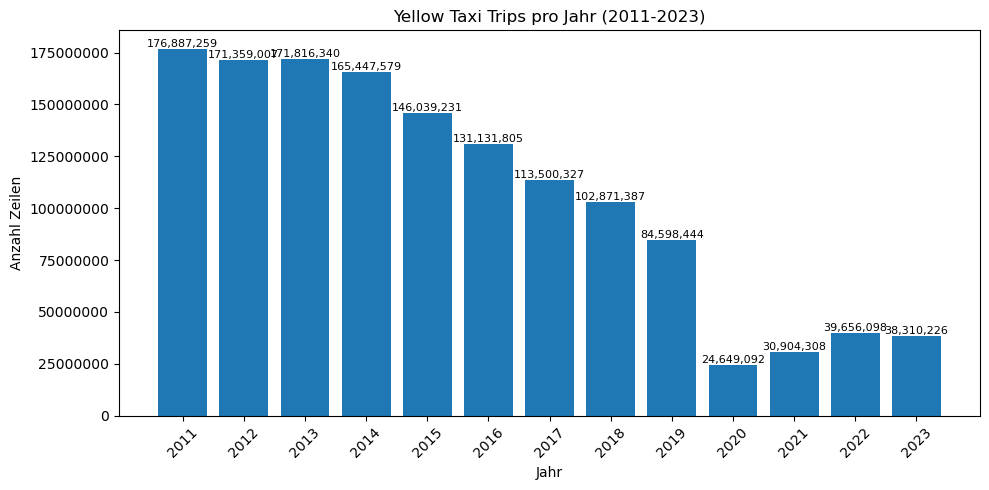

In [10]:
import matplotlib.pyplot as plt

years = [str(year) for year, rows, min_p, max_p in date_ranges]
rows = [rows for year, rows, min_p, max_p in date_ranges]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(years, rows, color="#1f77b4")

ax.set_title("Yellow Taxi Trips pro Jahr (2011-2023)")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl Zeilen")
ax.ticklabel_format(style="plain", axis="y")

# Werte ueber den Balken anzeigen
for bar, count in zip(bars, rows):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center", va="bottom", fontsize=8, rotation=0
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Stop session

In [ ]:
spark.stop()

---
## Uebersicht pro Datei

Zeilen, Spaltenanzahl (vor Normalisierung) und Groesse -- als Grundlage fuer die
Partitionierungs- und Ingestionsentscheidung im naechsten Schritt.

In [ ]:
header = "Datei".ljust(35) + "Zeilen".rjust(10) + "Spalten (roh)".rjust(16) + "Groesse (MB)".rjust(15)
print(header)
print("-" * 76)

for f in files:
    raw_df = spark.read.parquet(str(f))
    rows = raw_df.count()
    size_mb = f.stat().st_size / (1024 * 1024)
    row = f.name.ljust(35) + str(rows).rjust(10) + str(len(raw_df.columns)).rjust(16) + str(round(size_mb, 2)).rjust(15)
    print(row)

---
## Verschiedene File Types

Quick rundown of the four NYC TLC trip record types, since they're easy to conflate:

### Yellow Taxi

The classic NYC medallion cabs — the ones you can street-hail anywhere in Manhattan and pick up at airports. This is what you've been exploring so far (2009–present).

### Green Taxi ("Boro Taxi")

Introduced in August 2013 to serve the outer boroughs (Brooklyn, Queens, Bronx, Staten Island, and northern Manhattan) and areas yellow cabs historically underserved. Green cabs cannot pick up street-hails in Manhattan below 96th Street or at the airports — that's the core regulatory distinction from Yellow. Same general trip-record structure as Yellow (fare breakdown, pickup/dropoff, distance), but with an added trip_type field distinguishing street-hail vs. dispatched trips, and slightly different column naming conventions in earlier years.

### FHV (For-Hire Vehicle)

Traditional livery cabs, black cars, and small dispatch bases — the pre-app-era category of "you call a base, they send a car." Started 2015 in this dataset. Structurally very different from Yellow/Green: no itemized fare, no distance, no payment type — just the dispatching base's license number, pickup date/time, and pickup location zone ID. Far less detailed because these trips were self-reported by small bases with minimal standardized metering, unlike TPEP-equipped Yellow/Green cabs.

### HVFHV (High Volume For-Hire Vehicle)

This is Uber, Lyft, Via, Juno — split out as its own dataset starting February 2019, once TLC classified "high volume" FHV bases (dispatching >10,000 trips/day) under a separate reporting requirement. It's the most detailed of the FHV-family datasets: includes fare breakdown, driver pay, tips, shared-ride flags, and congestion surcharges — much closer in richness to Yellow/Green than to plain FHV, just for app-dispatched rides instead of street-hail taxis.